Number of intersections:  22794
Number of road segments: 62958


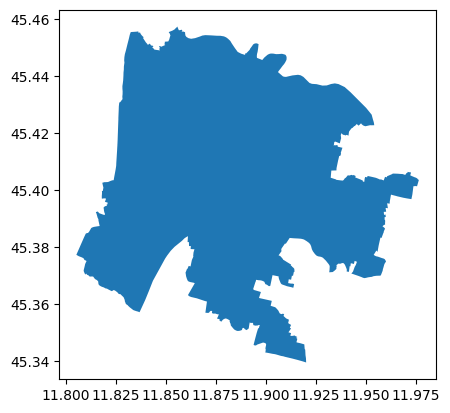

In [11]:
import osmnx as ox  

# Define the polygon for the 1st district of Budapest
# admin_district = ox.geocode_to_gdf('12th district, Budapest')
admin_district = ox.geocode_to_gdf('Padua')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [4]:
# Define the walking speed (5 km/h -> 1.39 m/s)
walking_speed = 1.39  # in meters per second

# Calculate travel time for each edge
for u, v, data in G.edges(data=True):
    # Calculate travel time in seconds
    data['travel_time'] = data['length'] / walking_speed

# Pick a center node
center_node = list(G.nodes())[30]  # starting point

# Generate isochrones
isochrone_times = [5, 10, 20, 30]  # isochrones in minutes

/tmp/ipykernel_278178/2499453853.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = Polygon(gpd.GeoSeries(node_points).unary_union.convex_hull)
/tmp/ipykernel_278178/2499453853.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = Polygon(gpd.GeoSeries(node_points).unary_union.convex_hull)
/tmp/ipykernel_278178/2499453853.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = Polygon(gpd.GeoSeries(node_points).unary_union.convex_hull)
/tmp/ipykernel_278178/2499453853.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = Polygon(gpd.GeoSeries(node_points).unary_union.convex_hull)


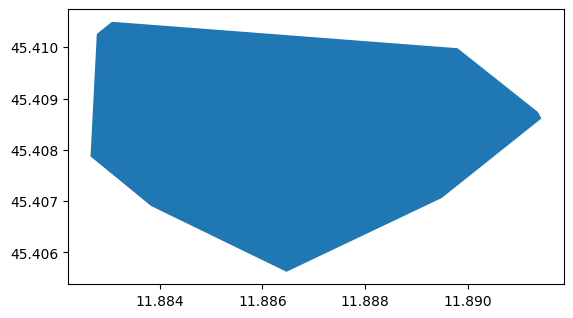

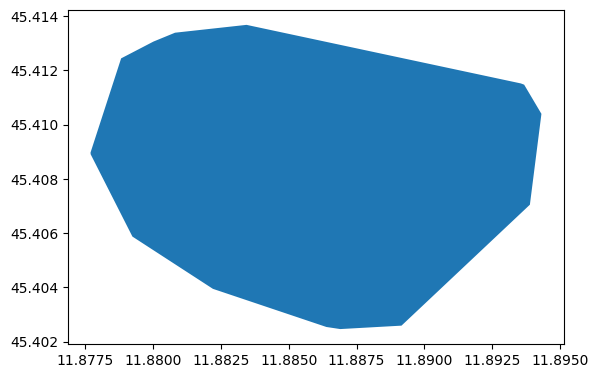

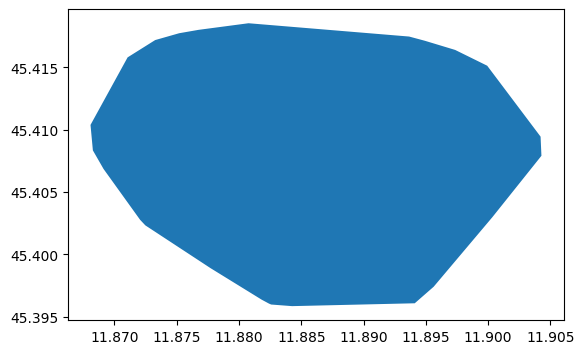

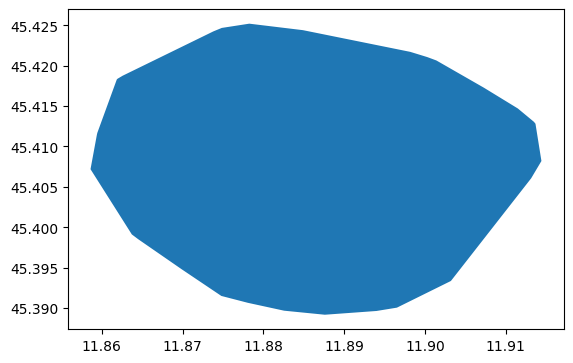

In [5]:
# Library imports
import networkx as nx 
from shapely.geometry import Point, Polygon  
import geopandas as gpd 

isochrone_polys = []

for time in isochrone_times:
    subgraph = nx.ego_graph(G, 
                            center_node, 
                            radius=time*60, 
                            distance='travel_time')

    node_points = [Point((data['x'], data['y'])) 
                   for node, data in subgraph.nodes(data=True)]

    polygon = Polygon(gpd.GeoSeries(node_points).unary_union.convex_hull)
    gpd.GeoDataFrame([polygon], columns = ['geometry']).plot()
    isochrone_polys.append(gpd.GeoSeries([polygon]))

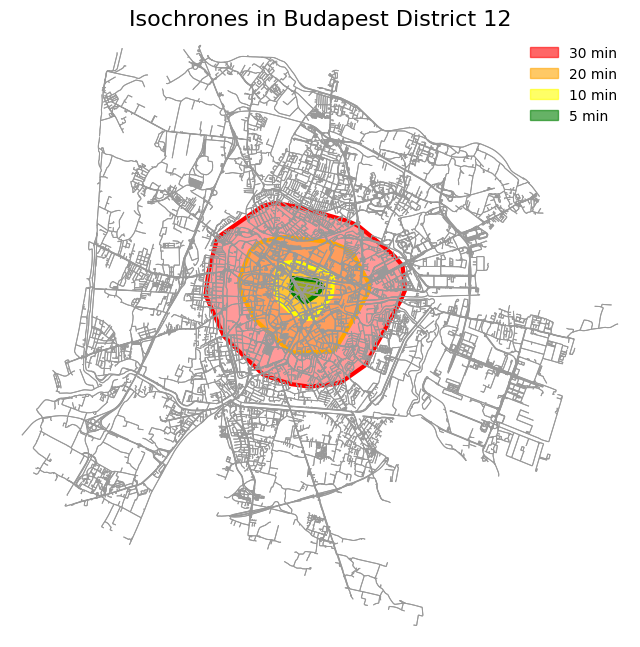

In [7]:
# import plotting libs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create visuals
fig, ax = plt.subplots(figsize=(8, 8))

# Define the colors of the isochrones
colors = ['red', 'orange', 'yellow', 'green']

# Plot the isochrones
for idx, (polygon, time) in enumerate(reversed(list(zip(isochrone_polys, isochrone_times)))):
    polygon.plot(ax=ax, color=colors[idx], alpha=0.4, label=f'{time} min')
    polygon.plot(ax=ax, color = 'none', edgecolor = colors[idx], linewidth = 3)

# Manually create legend handles
handles = [
    mpatches.Patch(color=colors[idx], alpha=0.6, label=f'{time} min')
    for idx, time in enumerate(reversed(isochrone_times))
]

# Plot the network
ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.7, show=False)

# Add the legend to the plot and set the title
ax.set_title('Isochrones in Budapest District 12', fontsize=16)
legend = plt.legend(handles=handles)
legend.get_frame().set_linewidth(0)  # Remove the legend box's frame

# Show the plot
plt.show()